# Aufgabe 4 - Interpretation von Satellitenbildern

#### Nice to know:
Band 1: Visible blue<br>
Band 2: Visible green<br>
Band 3: Visible red<br>
Band 4: Near infrared (NIR)<br>
Band 5: Middle infrared (MIR)<br>
Band 6: Thermal infrared (TIR)<br>
Band 7: Shortwave infrared (SWIR)<br>

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread

## 4.1

In [35]:
# Bilder einlesen und in einem Array speichern (inkl. Fehlerbehandlung)
try:
    imgs = [imread(f"landsatBild/band{idx}.png") for idx in range(1, 8)]

    # Konvertierung zu Float, damit die Arithmetik später korrekt funktioniert
    # uint8 kann nur (0-255), dies reicht aber nicht bei der Berechnung der Indizes
    imgs = [img.astype(np.float32) for img in imgs]
except FileNotFoundError:
    print("Fehler: Bitte stelle sicher, dass die Bilder im Verzeichnis 'landsatBild' vorhanden sind.")

# Mapping der Variablennamen für die einzelnen Bilder
BANDS = {
    "blue": imgs[0],
    "green": imgs[1],
    "red": imgs[2],
    "NIR": imgs[3],
    "MIR": imgs[4],
    "TIR": imgs[5],
    "SWIR": imgs[6]
}

#### Berechnung der Inidzes: NDVI, NDWI, NDSI, NDBI

In [36]:
# Warnung Division durch NULL ignorieren, da der Zähler des Bruchs auch 0 ist, wenn der Zähler 0 ist.
with np.errstate(divide='ignore', invalid='ignore'):
    ndvi = (BANDS["NIR"] - BANDS["red"]) / (BANDS["NIR"] + BANDS["red"])

    ndwi = (BANDS["NIR"] - BANDS["SWIR"]) / (BANDS["NIR"] + BANDS["SWIR"])

    ndsi = (BANDS["green"] - BANDS["SWIR"]) / (BANDS["green"] + BANDS["SWIR"])

    ndbi = (BANDS["MIR"] - BANDS["NIR"]) / (BANDS["MIR"] + BANDS["NIR"])

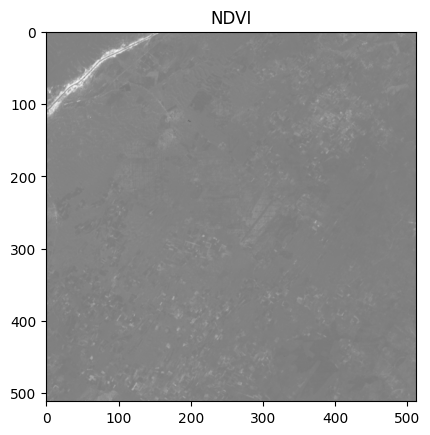

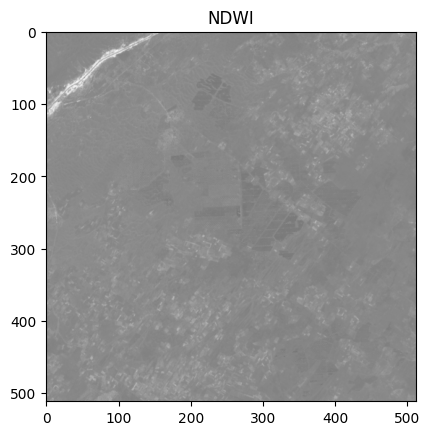

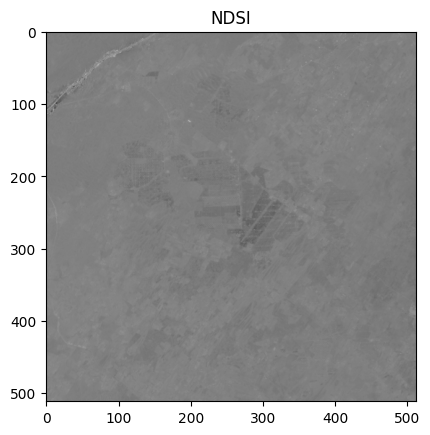

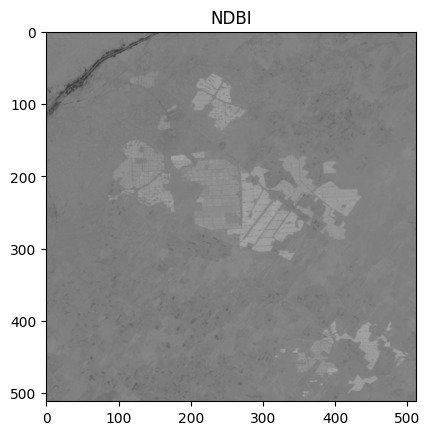

In [37]:
plt.title("NDVI")
plt.imshow(ndvi, cmap="gray", vmin=-1, vmax=1)
plt.show()

plt.title("NDWI")
plt.imshow(ndwi, cmap="gray", vmin=-1, vmax=1)
plt.show()

plt.title("NDSI")
plt.imshow(ndsi, cmap="gray", vmin=-1, vmax=1)
plt.show()

plt.title("NDBI")
plt.imshow(ndbi, cmap="gray", vmin=-1, vmax=1)
plt.show()

Da die dunklen Flächen im Echtfarben-Bild nur bei dem NDBI hohe Werte zugeordnet bekommen, handelt es sich um bebaute Flächen. Vermutung: Es handelt sich um Solarparks.
